In [1]:
! pip install earthaccess -U

import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

  Using cached earthaccess-0.17.0-py3-none-any.whl.metadata (6.7 kB)
Using cached earthaccess-0.17.0-py3-none-any.whl (76 kB)
  Attempting uninstall: earthaccess
    Found existing installation: earthaccess 0.16.0
    Uninstalling earthaccess-0.16.0:
      Successfully uninstalled earthaccess-0.16.0


In [2]:
# Authenticate using Earthdata Login prerequisite files
auth = earthaccess.login()

if not auth.authenticated:
    # Ask for credentials and persist them in a .netrc file.
    auth.login(strategy="interactive", persist=True)

print(earthaccess.__version__)

0.17.0


In [3]:
fires = {"fires": ["York", "Pilot", "Newell", "Elkhorn"], 
         "start_time": ["2023-07-28T12:00:00", "2023-07-01T12:00:00", "2023-07-22T00:00:00", "2023-07-25T00:00:00"], 
        "end_time": ["2023-07-31T12:00:00", "2023-07-10T00:00:00", "2023-07-26T12:00:00", "2023-08-18T00:00:00"], 
         "lon": [-115.22265, -113.32527, -120.35058, -115.2172],
         "lat": [35.25335, 34.9293, 45.82466, 45.55159] 
        }
fires = pd.DataFrame.from_dict(fires)

In [5]:
## GPM GMI (GPROF) Radiometer Precipitation Profiling

def generate_bounding_box(lon, lat, degrees = 2):
    """
    Generate a bounding box around a given lon/lat point.

    Args:
        lon (float):     Center longitude in decimal degrees (-180 to 180)
        lat (float):     Center latitude  in decimal degrees (-90  to  90)
        degrees (float): Half-width of the bounding box in degrees

    Returns:
        dict: Bounding box with min/max lon and lat values
    """
    min_lon = max(lon - degrees, -180)
    max_lon = min(lon + degrees,  180)
    min_lat = max(lat - degrees,  -90)
    max_lat = min(lat + degrees,   90)

    return (min_lon, min_lat, max_lon, max_lat)

results = earthaccess.search_data(
    #doi='10.5067/GPM/IMERGDF/DAY/07', # Daily
    #doi = '10.5067/GPM/IMERG/3B-HH/07', # Half Hourly
    count = -1, 
    doi = '10.5067/GPM/GMI/GPM/GPROF/2A/07', # GPROF
    cloud_hosted=True,
    temporal=("2023-07-28T00:00:00", "2023-07-31T12:00:00"),
    #point = (-115.22265, 35.25335)
    bounding_box = generate_bounding_box( lon = -115.22265, lat =35.25335, degrees = 2 )
)

In [6]:
## Trying email per-granual method  https://disc.gsfc.nasa.gov/information/howto?keywords=earthaccess&title=How%20to%20Directly%20Access%20GPM%20IMERG%20Data%20from%20an%20S3%20Bucket%20with%20Python





QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

In [42]:
# results = earthaccess.search_data( # for testing the example code
#     # TEMPO NO₂ Level-3 product
#     short_name="TEMPO_NO2_L3",
#     # Version 3 of the data product
#     version="V03",
#     # Time period: One week in January 2024 (times are in UTC)
#     temporal=("2024-01-11 12:00", "2024-01-18 12:00"),
#     count=8,
# )

In [43]:
fn = earthaccess.open(results)
#ds = xr.open_mfdataset(fn, group="Grid", concat_dim="time", combine="nested", coords="all",  data_vars="all") # concat_dim="time", combine="nested" # half hourly I think?

QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

In [44]:
# open_options = {
#     "access": "indirect",  # access to cloud data (faster in AWS with "direct")
#     "load": True,  # Load metadata immediately (required for indexing)
#     "concat_dim": "time",  # Concatenate files along the time dimension
#     "data_vars": "minimal",  # Only load data variables that include the concat_dim
#     "coords": "minimal",  # Only load coordinate variables that include the concat_dim
#     "compat": "override",  # Avoid coordinate conflicts by picking the first
#     "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
# }


open_options = {
    "access": "indirect",  # access to cloud data (faster in AWS with "direct")
    "load": True,  # Load metadata immediately (required for indexing)

    "data_vars": "minimal",  # Only load data variables that include the concat_dim
    "coords": None,  # Only load coordinate variables that include the concat_dim
    "compat": "override",  # Avoid coordinate conflicts by picking the first
    "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
}

In [45]:
# result_root = earthaccess.virtualize(granules=results, **open_options)
# result_product = earthaccess.virtualize(
#     granules=results, group="product", **open_options
# )
# result_geolocation = earthaccess.virtualize(
#     granules=results, group="geolocation", **open_options
# )

In [46]:
## Note: se this is diagnostic code for getting the group strucutre of the dataset

import h5py

with h5py.File(fn[0]) as f:
    f.visit(print)  # prints ALL groups and variables recursively

GprofDHeadr
GprofDHeadr/clusterProfiles
GprofDHeadr/hgtTopLayer
GprofDHeadr/speciesDescription
GprofDHeadr/temperatureDescriptions
S1
S1/L1CqualityFlag
S1/Latitude
S1/Longitude
S1/SCstatus
S1/SCstatus/FractionalGranuleNumber
S1/SCstatus/SCaltitude
S1/SCstatus/SClatitude
S1/SCstatus/SClongitude
S1/SCstatus/SCorientation
S1/ScanTime
S1/ScanTime/DayOfMonth
S1/ScanTime/DayOfYear
S1/ScanTime/Hour
S1/ScanTime/MilliSecond
S1/ScanTime/Minute
S1/ScanTime/Month
S1/ScanTime/Second
S1/ScanTime/SecondOfDay
S1/ScanTime/Year
S1/airmassLiftIndex
S1/cloudWaterPath
S1/convectivePrecipitation
S1/frozenPrecipitation
S1/iceWaterPath
S1/mostLikelyPrecipitation
S1/pixelStatus
S1/precip1stTertial
S1/precip2ndTertial
S1/precipitationYesNoFlag
S1/probabilityOfPrecip
S1/profileNumber
S1/profileScale
S1/profileTemp2mIndex
S1/qualityFlag
S1/rainWaterPath
S1/sunGlintAngle
S1/sunLocalTime
S1/surfacePrecipitation
S1/surfaceTypeIndex
S1/temp2mIndex
S1/totalColumnWaterVaporIndex


 # Lazy loading based on virtual dataset

Based on [this example](https://earthaccess.readthedocs.io/en/latest/user/tutorials/virtual_dataset_tutorial_with_TEMPO_Level3/#opening-virtual-multifile-datasets).   

In [48]:
# #%%time
# #result_root = earthaccess.virtualize(granules=results, **open_options)

# result_s1 = earthaccess.virtualize(
#     granules=results, group="S1", **open_options
# )

# result_header = earthaccess.virtualize(
#     granules=results, group="GprofDHeadr", **open_options
# )
# # merge
# #result_merged = xr.merge([result_root, result_product, result_geolocation])
# #result_merged

In [49]:
# # ------------------------------------------------------------------
# # 1. Search and open files
# # ------------------------------------------------------------------
# results = earthaccess.search_data(
#     doi='10.5067/GPM/GMI/GPM/GPROF/2A/07',
#     temporal=("2023-07-28T12:00:00", "2023-07-31T12:00:00"),
#     point=(-115.22265, 35.25335)
# )

# fn = earthaccess.open(results)
    

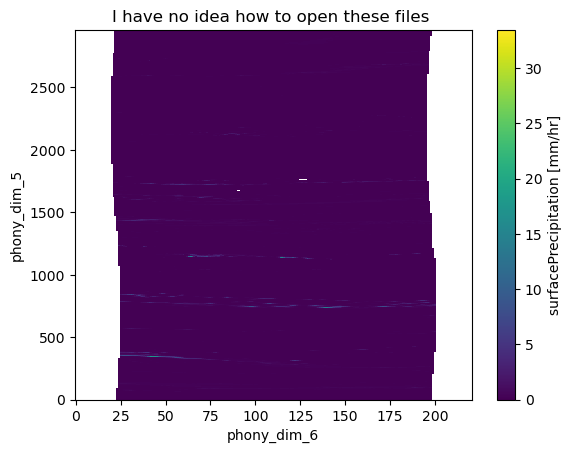

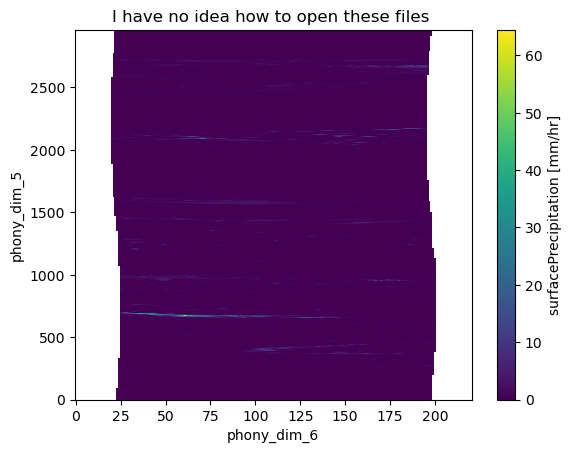

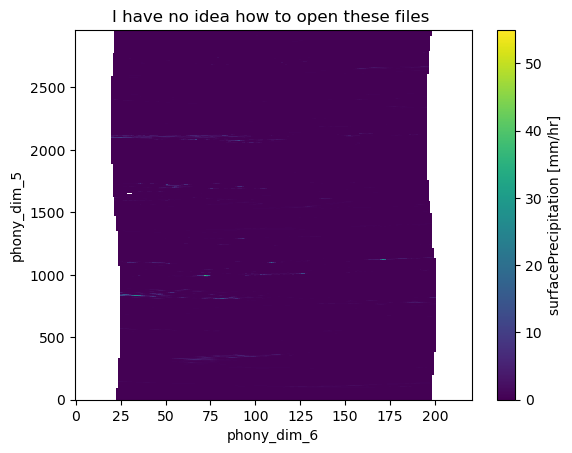

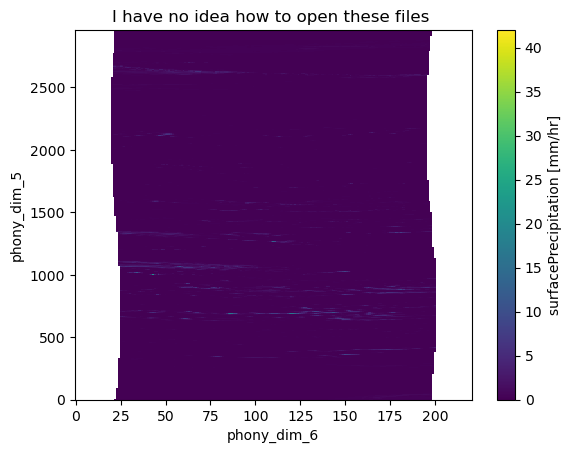

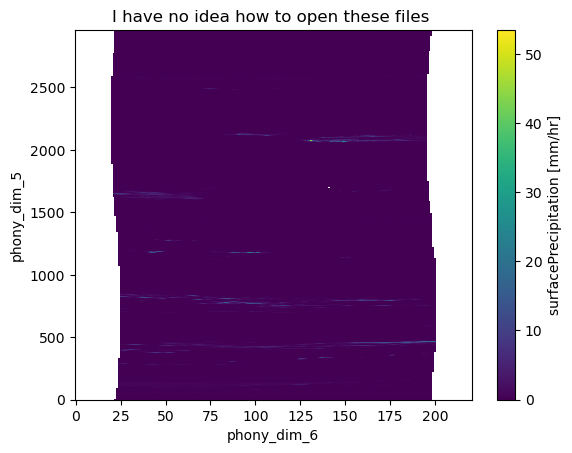

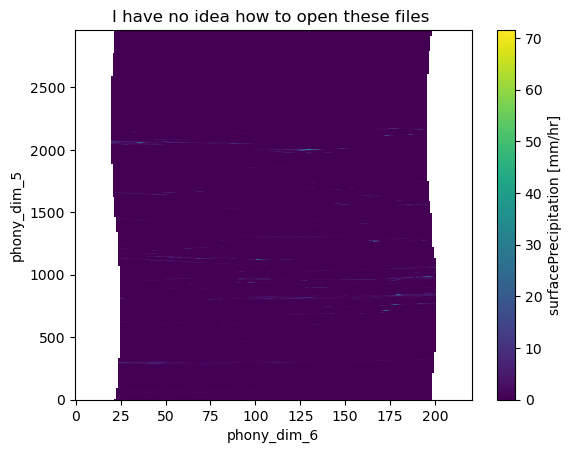

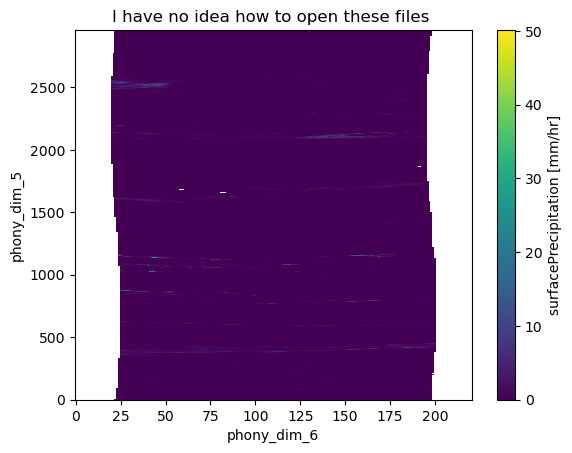

In [64]:
for f in fn:
    tmp = xr.open_datatree(f, engine="h5netcdf", phony_dims="access")
    tmp['S1']['surfacePrecipitation'].plot()
    plt.title(f"I have no idea how to open these files ")

    plt.show()

In [20]:
# # ------------------------------------------------------------------
# # 2. Open files individually, renaming phony dims immediately
# # ------------------------------------------------------------------
# ds_list = []
# scantime_list = []

# for f in fn:
#     ds_single = xr.open_dataset(
#         f,
#         group="S1",
#         engine="h5netcdf",
#         phony_dims="access",
#     ).rename({
#         "phony_dim_0": "nscan",
#         "phony_dim_1": "npixel",
#         "phony_dim_2": "nspecies"
#     })
#     ds_list.append(ds_single)

#     st_single = xr.open_dataset(
#         f,
#         group="S1/ScanTime",
#         engine="h5netcdf",
#         phony_dims="access",
#     ).rename({
#         "phony_dim_3": "nscan",
#     })
#     scantime_list.append(st_single)

# # ------------------------------------------------------------------
# # 3. Concatenate along nscan
# # ------------------------------------------------------------------
# ds = xr.concat(ds_list, dim="nscan", coords="minimal", compat="override")
# ds_scantime = xr.concat(scantime_list, dim="nscan", coords="minimal", compat="override")

# # ------------------------------------------------------------------
# # 4. Reconstruct time from ScanTime subgroup
# #    Cast to int to avoid dtype/byte-swapping issues from HDF5
# #    Missing values: Year=-9999, others=-99
# # ------------------------------------------------------------------
# year   = ds_scantime["Year"].values.astype(int)
# month  = ds_scantime["Month"].values.astype(int)
# day    = ds_scantime["DayOfMonth"].values
# hour   = ds_scantime["Hour"].values
# minute = ds_scantime["Minute"].values
# second = ds_scantime["Second"].values.astype(int)
# #DoY = ds_scantime["DayOfYear"].values.astype(int)

# # Mask out missing values before constructing timestamps
# valid = (year != -9999) & (month != -99) & (day != -99) & \
#         (hour != -99) & (minute != -99) & (second != -99) #& (DoY != -9999)

# # Build time array, filling invalid scans with NaT
# time = np.where(
#     valid,
#     pd.to_datetime({
#         "year":   np.where(valid, year,   2000),  # placeholder for invalid
#         "month":  np.where(valid, month,  1),
#         "day":    np.where(valid, day,    1),
#         "hour":   np.where(valid, hour,   0),
#         "minute": np.where(valid, minute, 0),
#         "second": np.where(valid, second, 0)#,
#         #"doy" : np.where(valid, DoY, 0)
#     }),
#     pd.NaT
# )

# time = pd.DatetimeIndex(time)

# # ------------------------------------------------------------------
# # 5. Assign coordinates
# #    Note: Lat/Lon are (npixel x nscan) per the docs,
# #    so we transpose to (nscan x npixel) for convenience
# # ------------------------------------------------------------------
# ds = ds.assign_coords(
#     time=(["nscan"], time),
#     latitude=(["nscan", "npixel"], ds["Latitude"].values.T),
#     longitude=(["nscan", "npixel"], ds["Longitude"].values.T),
# )

# # ------------------------------------------------------------------
# # 6. Mask missing values
# #    Float variables:   -9999.9
# #    Short integers:    -9999
# #    Byte integers:     -99
# # ------------------------------------------------------------------
# ds = ds.where(ds != -9999.9)

# print(ds)

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

ValueError: cannot assemble the datetimes: time data "2505600020230700" doesn't match format "%Y%m%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

NameError: name 'ds_scantime' is not defined

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

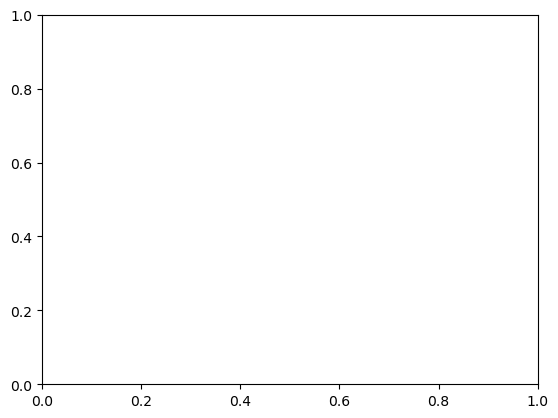

In [32]:
f, (ax1) = plt.subplots()

# The first plot (in kelvins) chooses "viridis" and uses the data's min/max
ds.plot(ax=ax1, cbar_kwargs={"label": "precip mm/hr"})
ax1.set_title("York Fire")


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

precipitation


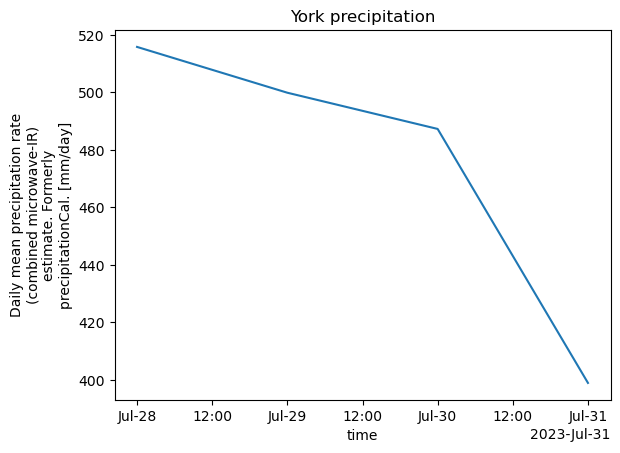

precipitation_cnt


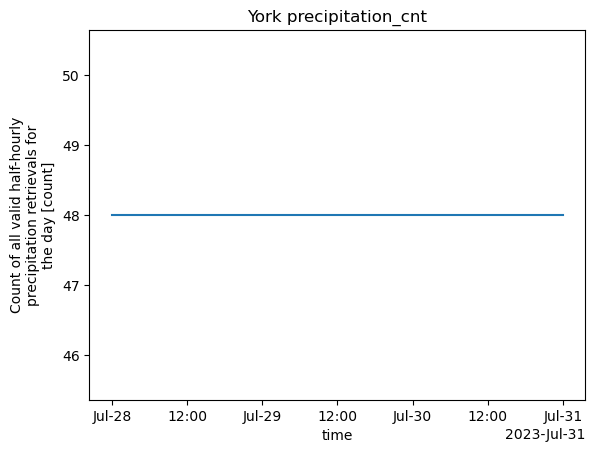

precipitation_cnt_cond


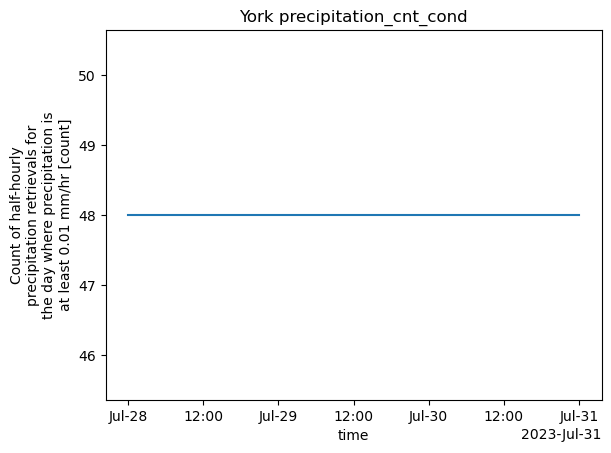

MWprecipitation


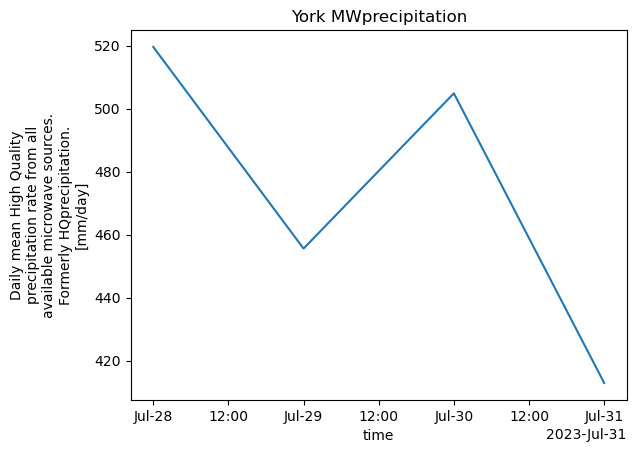

MWprecipitation_cnt


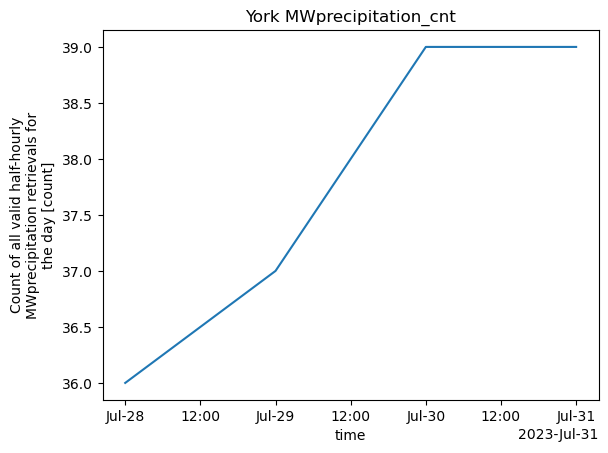

MWprecipitation_cnt_cond


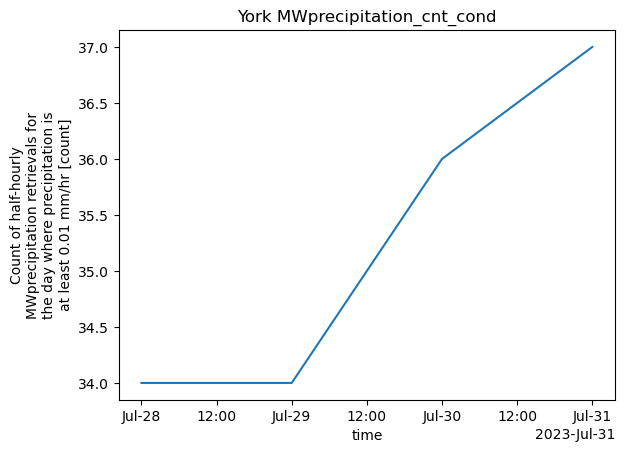

randomError


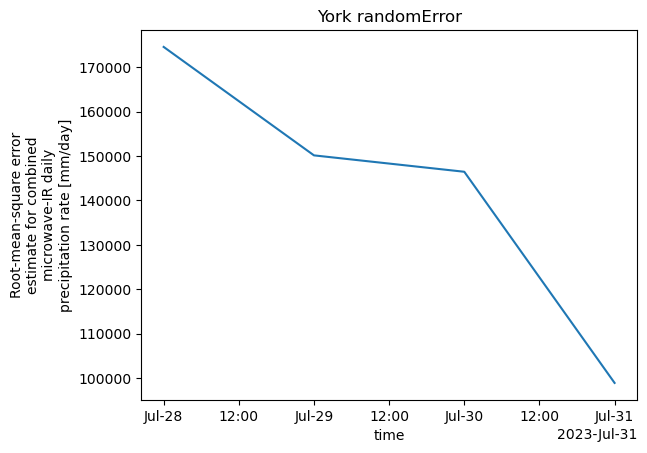

randomError_cnt


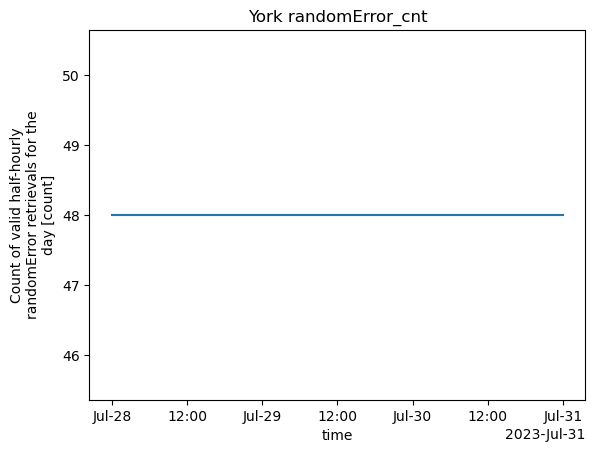

probabilityLiquidPrecipitation


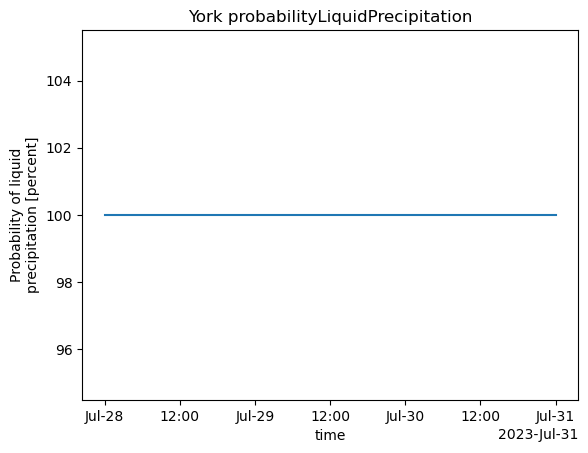

time_bnds


In [16]:
# Search for the granule by DOI
#for i in range(0, len(fires)):
i = 0
fires.loc[i, :]
# results = earthaccess.search_data(
#     # doi='10.5067/GPM/IMERGDF/DAY/07', # Daily
#     doi = '10.5067/GPM/IMERG/3B-HH/07', # half-hourly
#     temporal=(fires.loc[i, :]["start_time"], fires.loc[i, :]["end_time"]),
#     point = (fires.loc[i, :].lon, fires.loc[i, :].lat)
# )


results = earthaccess.search_data(
    doi='10.5067/GPM/IMERGDF/DAY/07', # Daily
    #doi = '10.5067/GPM/IMERG/3B-HH/07', # half-hourly
    temporal=("2023-07-28T12:00:00", "2023-07-31T12:00:00"),
    point = (-115.22265, 35.25335)
)

fn = earthaccess.open(results)
ds = xr.open_mfdataset(fn) 

    #ds.plot.scatter(x = "time", y = "precipitation", title = fires.loc[i, :].fires)
    
spatial_dims = ["lat", "lon"]
agg = getattr(ds["precipitation"], "max")(dim=spatial_dims)

fires_v = fires.copy()
for var in ds.data_vars:
    print(var)
    if (var != "time_bnds"):
    #fires_v.loc[fires.loc[i, :].fires == fires_v.fires, var] == getattr(ds[var], "max")(dim=spatial_dims)
        agg2 = getattr(ds[var], "max")(dim=spatial_dims)
        agg2.plot()
        plt.title(f"{fires.loc[i, :].fires} {var}")
        plt.show()
    
    
   #  #df = agg.to_dataframe(name = name_value).reset_index()
   #  for col in fires.index:
   #      #df[col] = events[col]
   #      try:
   #          df.loc[:, col] = events[col]
   #      except:
            # print(f"Exception: key error in {col}.")